In [ ]:
# from network.N_BPMSNet import N_BPMSNet, N_BPMSNet_Lite_v1,N_BPMSNet_Lite_v2,
from network.N_BPMSNet import N_BPMSNet_Lite_v3
import torch
import numpy as np
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# model = N_BPMSNet()
# model_path = './output/N_BPMSNet_best_iou.pth'
# model = N_BPMSNet_Lite_v1()
# model_path = './output/N_BPMSNet_Lite_v1_best_iou.pth'
# model = N_BPMSNet_Lite_v2()
# model_path = './output/N_BPMSNet_Lite_v2_best_iou.pth'
model = N_BPMSNet_Lite_v3()
model_path = "./output/N_BPMSNet_Lite_v3_best_iou.pth"
model.load_state_dict(torch.load(model_path, map_location=torch.device("cpu")))
model.eval()

In [ ]:
device = torch.device("cpu")
model.train(False)
model.eval()

WHITE = (255, 255, 255)  # TP
BLACK = (0, 0, 0)  # TN
RED = (255, 0, 0)  # FP
BLUE = (0, 0, 255)  # FN

next_indexs = [
    1201,
    1241,
    3523,
    4020,
    4030,
    4275,
    4511,
    4773,
    4795,
    6278,
    6530,
    8821,
    9309,
    10789,
    10791,
    13607,
]
for i, index in enumerate(
    [
        1200,
        1240,
        3521,
        4017,
        4029,
        4274,
        4510,
        4772,
        4794,
        6275,
        6527,
        8814,
        9305,
        10788,
        10789,
        13606,
    ]
):
    target = (
        np.array(
            Image.open("../../dataset/mask_gray/" + str(index) + ".jpg").convert("L")
        )
        / 255
    )
    context_1 = np.load("../../dataset/s2/" + str(index) + ".npy")
    context_2 = np.load("../../dataset/s2/" + str(next_indexs[i]) + ".npy")

    ndmi_C1 = (context_1[11, ...] - context_1[12, ...]) / (
        context_1[11, ...] + context_1[12, ...]
    )
    ndmi_C2 = (context_2[11, ...] - context_2[12, ...]) / (
        context_2[11, ...] + context_2[12, ...]
    )
    ndmi_C3 = ndmi_C1 - ndmi_C2
    ndmi_C1 = np.expand_dims(ndmi_C1, axis=0)
    ndmi_C2 = np.expand_dims(ndmi_C2, axis=0)
    ndmi_C3 = np.expand_dims(ndmi_C3, axis=0)
    context_3 = np.concatenate([ndmi_C1, ndmi_C2, ndmi_C3], axis=0)

    mid_loc_x = context_1.shape[1] // 2
    mid_loc_y = context_1.shape[2] // 2
    s = 80
    context_1 = context_1[
        :, mid_loc_x - s : mid_loc_x + s, mid_loc_y - s : mid_loc_y + s
    ]
    context_2 = context_2[
        :, mid_loc_x - s : mid_loc_x + s, mid_loc_y - s : mid_loc_y + s
    ]
    context_3 = context_3[
        :, mid_loc_x - s : mid_loc_x + s, mid_loc_y - s : mid_loc_y + s
    ]
    target = target[mid_loc_x - s : mid_loc_x + s, mid_loc_y - s : mid_loc_y + s]

    context_1 = torch.Tensor(context_1).unsqueeze(0).to(device)
    context_2 = torch.Tensor(context_2).unsqueeze(0).to(device)
    context_3 = torch.Tensor(context_3).unsqueeze(0).to(device)

    preds = model(context_1, context_2, context_3)

    predictions = F.sigmoid(preds[-1]).detach().cpu().numpy()[0, 0]
    predictions = (predictions >= 0.5).astype(np.uint8)

    # 初始化彩色图 (H, W, 3)
    H, W = predictions.shape
    color_mask = np.zeros((H, W, 3), dtype=np.uint8)

    # 计算四类
    TP = (predictions == 1) & (target == 1)
    TN = (predictions == 0) & (target == 0)
    FP = (predictions == 1) & (target == 0)
    FN = (predictions == 0) & (target == 1)

    # 上色
    color_mask[TP] = WHITE
    color_mask[TN] = BLACK
    color_mask[FP] = RED
    color_mask[FN] = BLUE

    print(index)
    plt.imshow(color_mask)
    # plt.title("Comparison (TP/TN/FP/FN)")
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.show()

In [ ]:
index, next_index = 13606, 13607
device = torch.device("cpu")
model.train(False)
model.eval()

context_1 = np.load("../../dataset/s2/{}.npy".format(index))  # 1192, 1032
context_2 = np.load("../../dataset/s2/{}.npy".format(next_index))  # 1193, 1033

ndmi_C1 = (context_1[11, ...] - context_1[12, ...]) / (
    context_1[11, ...] + context_1[12, ...]
)
ndmi_C2 = (context_2[11, ...] - context_2[12, ...]) / (
    context_2[11, ...] + context_2[12, ...]
)
ndmi_C3 = ndmi_C1 - ndmi_C2
ndmi_C1 = np.expand_dims(ndmi_C1, axis=0)
ndmi_C2 = np.expand_dims(ndmi_C2, axis=0)
ndmi_C3 = np.expand_dims(ndmi_C3, axis=0)
context_3 = np.concatenate([ndmi_C1, ndmi_C2, ndmi_C3], axis=0)

mid_loc_x = context_1.shape[1] // 2
mid_loc_y = context_1.shape[2] // 2
s = 80
context_1 = context_1[:, mid_loc_x - s : mid_loc_x + s, mid_loc_y - s : mid_loc_y + s]
context_2 = context_2[:, mid_loc_x - s : mid_loc_x + s, mid_loc_y - s : mid_loc_y + s]
context_3 = context_3[:, mid_loc_x - s : mid_loc_x + s, mid_loc_y - s : mid_loc_y + s]

context_1 = torch.Tensor(context_1).unsqueeze(0).to(device)
context_2 = torch.Tensor(context_2).unsqueeze(0).to(device)
context_3 = torch.Tensor(context_3).unsqueeze(0).to(device)

preds = model(context_1, context_2, context_3)

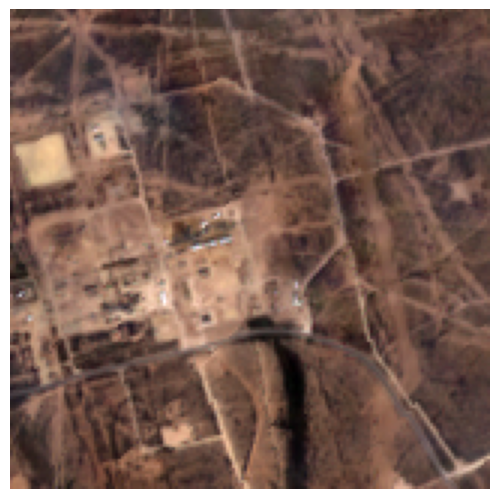

In [ ]:
def nor_img(channel_data):
    min_value = channel_data.min()
    max_value = channel_data.max()
    normalized_data = (channel_data - min_value) / (max_value - min_value)
    return normalized_data


def RGB_img(data):
    channel_data2 = nor_img(data[3])
    channel_data3 = nor_img(data[2])
    channel_data4 = nor_img(data[1])
    channel_data = np.dstack((channel_data2, channel_data3, channel_data4))
    return channel_data


plt.imshow(RGB_img(context_1[0]))
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

In [ ]:
predictions = F.sigmoid(preds[-1]).detach().cpu().numpy()[0, 0]
predictions = (predictions >= 0.5).astype(np.uint8)

target = (
    np.array(Image.open("../../dataset/mask_gray/{}.jpg".format(index)).convert("L"))
    // 255
)
mid_loc_x = target.shape[0] // 2
mid_loc_y = target.shape[1] // 2
target = target[mid_loc_x - s : mid_loc_x + s, mid_loc_y - s : mid_loc_y + s]
target = target.astype(np.uint8)

H, W = predictions.shape
color_mask = np.zeros((H, W, 3), dtype=np.uint8)

WHITE = (255, 255, 255)  # TP
BLACK = (0, 0, 0)  # TN
RED = (255, 0, 0)  # FP
BLUE = (0, 0, 255)  # FN

TP = (predictions == 1) & (target == 1)
TN = (predictions == 0) & (target == 0)
FP = (predictions == 1) & (target == 0)
FN = (predictions == 0) & (target == 1)

color_mask[TP] = WHITE
color_mask[TN] = BLACK
color_mask[FP] = RED
color_mask[FN] = BLUE

# plt.imshow(predictions, cmap="gray")
# # plt.title("Prediction Mask")
# plt.axis("off")
# plt.tight_layout(pad=0)
# plt.show()

plt.imshow(target, cmap="gray")
# plt.title("Target Mask")
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

plt.imshow(color_mask)
# plt.title("Comparison (TP/TN/FP/FN)")
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

In [ ]:
plt.imshow(RGB_img())

In [ ]:
WHITE = (255, 255, 255)  # TP
BLACK = (0, 0, 0)  # TN
RED = (255, 0, 0)  # FP
BLUE = (0, 0, 255)  # FN
test = pd.read_csv("../../dataset/test.csv")
for ind, row in test[test["plume"] == 2].iterrows():
    index, next_index = row["index"], row["next_index"]
    print(index)
    context_1 = np.load("../../dataset/s2/{}.npy".format(index))
    context_2 = np.load("../../dataset/s2/{}.npy".format(next_index))

    ndmi_C1 = (context_1[11, ...] - context_1[12, ...]) / (
        context_1[11, ...] + context_1[12, ...]
    )
    ndmi_C2 = (context_2[11, ...] - context_2[12, ...]) / (
        context_2[11, ...] + context_2[12, ...]
    )
    ndmi_C3 = ndmi_C1 - ndmi_C2
    ndmi_C1 = np.expand_dims(ndmi_C1, axis=0)
    ndmi_C2 = np.expand_dims(ndmi_C2, axis=0)
    ndmi_C3 = np.expand_dims(ndmi_C3, axis=0)
    context_3 = np.concatenate([ndmi_C1, ndmi_C2, ndmi_C3], axis=0)

    mid_loc_x = context_1.shape[1] // 2
    mid_loc_y = context_1.shape[2] // 2
    s = 80
    context_1 = context_1[
        :, mid_loc_x - s : mid_loc_x + s, mid_loc_y - s : mid_loc_y + s
    ]
    context_2 = context_2[
        :, mid_loc_x - s : mid_loc_x + s, mid_loc_y - s : mid_loc_y + s
    ]
    context_3 = context_3[
        :, mid_loc_x - s : mid_loc_x + s, mid_loc_y - s : mid_loc_y + s
    ]

    context_1 = torch.Tensor(context_1).unsqueeze(0).to(device)
    context_2 = torch.Tensor(context_2).unsqueeze(0).to(device)
    context_3 = torch.Tensor(context_3).unsqueeze(0).to(device)

    preds = model(context_1, context_2, context_3)

    predictions = F.sigmoid(preds[-1]).detach().cpu().numpy()[0, 0]
    predictions = (predictions >= 0.5).astype(np.uint8)

    target = (
        np.array(
            Image.open("../../dataset/mask_gray/{}.jpg".format(index)).convert("L")
        )
        // 255
    )
    mid_loc_x = target.shape[0] // 2
    mid_loc_y = target.shape[1] // 2
    target = target[mid_loc_x - s : mid_loc_x + s, mid_loc_y - s : mid_loc_y + s]
    target = target.astype(np.uint8)

    H, W = predictions.shape
    color_mask = np.zeros((H, W, 3), dtype=np.uint8)

    TP = (predictions == 1) & (target == 1)
    TN = (predictions == 0) & (target == 0)
    FP = (predictions == 1) & (target == 0)
    FN = (predictions == 0) & (target == 1)

    color_mask[TP] = WHITE
    color_mask[TN] = BLACK
    color_mask[FP] = RED
    color_mask[FN] = BLUE

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(predictions, cmap="gray")
    plt.title("Prediction Mask")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(target, cmap="gray")
    plt.title("Target Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(color_mask)
    plt.title("Comparison (TP/TN/FP/FN)")
    plt.axis("off")

    plt.savefig("./res_image/" + str(index) + ".png", dpi=300, bbox_inches="tight")

In [ ]:
from matplotlib import pyplot as plt

plt.imshow(preds[0].detach().numpy()[0, 0])
plt.show()
plt.imshow(preds[1].detach().numpy()[0, 0])
plt.show()
plt.imshow(preds[2].detach().numpy()[0, 0])
plt.show()
plt.imshow(preds[3].detach().numpy()[0, 0])
plt.colorbar()
plt.show()
predictions = F.sigmoid(preds[-1])
predictions[predictions >= 0.5] = 1
predictions[predictions < 0.5] = 0
plt.imshow(predictions.detach().numpy()[0, 0], cmap="gray")
plt.show()

In [ ]:
plt.imshow(context_3[0, 2], cmap="bwr", vmin=-0.05, vmax=0.05)
# plt.imshow(context_3[0,2],cmap='bwr',vmin=-0.01,vmax=0.01)
plt.colorbar()
plt.show()
plt.imshow(context_3[0, 0], cmap="bwr", vmin=-0.5, vmax=0.5)
plt.colorbar()
plt.show()

In [ ]:
plt.imshow(context_2[0, 1])
plt.show()

In [ ]:
target = (
    np.array(Image.open("../../dataset/mask_gray/{}.jpg".format(index)).convert("L"))
    / 255
)